# Importing library

In [3]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

In [4]:
df_input = pd.read_csv(
    'weather-energy-data-update (1).csv',
    parse_dates=['Datetime']
)

In [5]:
df_input.set_index('Datetime', inplace=True)

### EDA

In [6]:
df_input.shape

(26328, 17)

In [7]:
df_input.sample(5)

,kWh,hour,day_of_month,day_of_week,month,is_weekend,pressure_at_sea,precip_dur_past10min,wind_dir,wind_speed,temp_dew,pressure,visib_mean_last10min,temp_dry,humidity,cloud_cover,visibility
Datetime,,,,,,,,,,,,,,,,,
2019-02-22 12:00:00,0.354,12.0,22.0,4.0,2.0,0,1042.050000,0.000000,144.166667,5.883333,-1.266667,1034.866667,46250.00000,2.266667,77.500000,90.000000,45833.33333
2019-05-02 02:00:00,0.197,2.0,2.0,3.0,5.0,0,1001.566667,0.000000,283.666667,5.783333,4.766667,994.800000,37616.66667,7.566667,82.333333,100.000000,34833.33333
2019-03-14 14:00:00,0.077,14.0,14.0,3.0,3.0,0,985.500000,0.333333,205.500000,4.883333,3.283333,978.800000,21866.66667,4.600000,91.500000,98.333333,21000.00000
2019-07-28 10:00:00,0.161,10.0,28.0,6.0,7.0,1,1007.983333,0.666667,87.500000,4.350000,17.100000,1001.466667,16566.66667,19.216667,87.666667,83.333333,16166.66667
2020-10-20 10:00:00,0.078,10.0,20.0,1.0,10.0,0,1010.366667,0.000000,150.333333,6.016667,5.050000,1003.600000,39400.00000,9.600000,73.000000,65.000000,39166.66667


In [8]:
df_input["kWh"].quantile(0.99)


np.float64(1.075)

In [9]:
df_input[df_input["kWh"]>2]

,kWh,hour,day_of_month,day_of_week,month,is_weekend,pressure_at_sea,precip_dur_past10min,wind_dir,wind_speed,temp_dew,pressure,visib_mean_last10min,temp_dry,humidity,cloud_cover,visibility
Datetime,,,,,,,,,,,,,,,,,
2019-03-03 20:00:00,2.053,20.0,3.0,6.0,3.0,1,992.850000,0.0,193.000000,3.166667,4.300000,986.066667,9033.333333,5.300000,93.166667,100.000000,8333.333333
2019-10-01 20:00:00,2.023,20.0,1.0,1.0,10.0,0,997.916667,0.0,266.166667,2.783333,4.550000,991.166667,39783.333330,7.250000,83.000000,0.000000,37500.000000
2020-03-19 22:00:00,2.072,22.0,19.0,3.0,3.0,0,1025.733333,0.0,264.500000,3.350000,2.583333,1018.750000,17800.000000,3.866667,91.166667,8.333333,17333.333330
2020-10-09 20:00:00,2.438,20.0,9.0,4.0,10.0,0,1011.200000,0.0,180.166667,2.850000,8.250000,1004.433333,41733.333330,9.000000,95.500000,100.000000,39500.000000
2020-12-19 20:00:00,2.429,20.0,19.0,5.0,12.0,1,1012.550000,0.5,184.000000,4.700000,5.116667,1005.700000,6483.333333,5.583333,96.833333,91.666667,6166.666667
2020-12-19 21:00:00,2.135,21.0,19.0,5.0,12.0,1,1012.733333,0.0,181.500000,5.200000,5.950000,1005.916667,5800.000000,6.400000,96.833333,100.000000,5633.333333
2021-04-10 20:00:00,2.126,20.0,10.0,5.0,4.0,1,1016.883333,0.0,170.000000,0.350000,-1.133333,1009.900000,48500.000000,0.916667,86.166667,6.666667,45833.333330


##### Get correlations

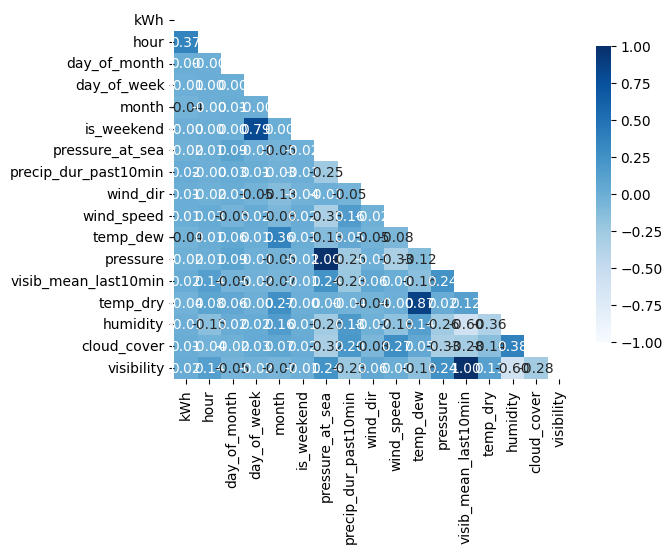

In [10]:
df_input_corr = df_input.corr()
# Create mask
mask = np.triu(np.ones_like(df_input_corr, dtype=bool))
# Plot heatmap
sns.heatmap(df_input_corr, mask=mask, annot=True, fmt=".2f", cmap='Blues',
            vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.show()

In [11]:
import warnings
warnings.filterwarnings("ignore")

#### import libraries for time series analysis

In [1]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # for determining (p,q) orders
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.eval_measures import mse,rmse
from sklearn.metrics import mean_absolute_percentage_error as maperror    # for ETS Plots
from pmdarima import auto_arima

#### Slicing the DataFrame by date range


In [12]:
df_input = df_input['20201001':'20211031']

#### This slices the DataFrame to include only the data between October 1, 2020, and October 31, 2021.

In [13]:
df_input.shape

(9504, 17)

In [14]:
df_input.sample(5)

,kWh,hour,day_of_month,day_of_week,month,is_weekend,pressure_at_sea,precip_dur_past10min,wind_dir,wind_speed,temp_dew,pressure,visib_mean_last10min,temp_dry,humidity,cloud_cover,visibility
Datetime,,,,,,,,,,,,,,,,,
2021-09-10 12:00:00,0.078,12.0,10.0,4.0,9.0,0,1011.733333,0.0,205.333333,2.566667,16.000000,1005.233333,17433.33333,20.200000,77.333333,90.000000,17333.333330
2020-12-09 22:00:00,0.427,22.0,9.0,2.0,12.0,0,1011.583333,0.0,173.500000,3.033333,2.616667,1004.683333,5350.00000,3.716667,92.500000,100.000000,4983.333333
2021-02-19 18:00:00,0.343,18.0,19.0,4.0,2.0,0,1014.700000,0.0,185.500000,3.416667,1.883333,1007.766667,11333.33333,2.583333,95.333333,54.166667,11000.000000
2021-05-17 22:00:00,0.220,22.0,17.0,0.0,5.0,0,1005.300000,0.0,260.000000,1.183333,6.483333,998.533333,10833.33333,7.033333,96.166667,39.166667,10500.000000
2021-09-08 04:00:00,0.077,4.0,8.0,2.0,9.0,0,1020.216667,0.0,244.500000,1.916667,13.000000,1013.516667,11966.66667,15.583333,84.500000,96.666667,11500.000000


In [15]:
df_input[['kWh', 'hour']]

,kWh,hour
Datetime,,
2020-10-01 00:00:00,0.419,0.0
2020-10-01 01:00:00,0.319,1.0
2020-10-01 02:00:00,0.094,2.0
2020-10-01 03:00:00,0.127,3.0
2020-10-01 04:00:00,0.113,4.0
...,...,...
2021-10-31 19:00:00,0.336,19.0
2021-10-31 20:00:00,0.749,20.0
2021-10-31 21:00:00,0.149,21.0


### Data Preparation for Time Series Modeling

In [16]:
df_H = df_input[['kWh', 'hour']]
df_H['hour'] = df_H['hour'].astype("category")

In [23]:
df_H.shape

(9504, 2)

In [24]:
df_H.head()

,kWh,hour
Datetime,,
2020-10-01 00:00:00,0.419,0.0
2020-10-01 01:00:00,0.319,1.0
2020-10-01 02:00:00,0.094,2.0
2020-10-01 03:00:00,0.127,3.0
2020-10-01 04:00:00,0.113,4.0


In [25]:
df_H.isna().sum()

kWh     0
hour    0
dtype: int64

#### Dataset contains no missing values

In [17]:
df_H['hour'].value_counts()

hour
0.0     396
1.0     396
2.0     396
3.0     396
4.0     396
5.0     396
6.0     396
7.0     396
8.0     396
9.0     396
10.0    396
11.0    396
12.0    396
13.0    396
14.0    396
15.0    396
16.0    396
17.0    396
18.0    396
19.0    396
20.0    396
21.0    396
22.0    396
23.0    396
Name: count, dtype: int64

In [18]:
df_H_dummies = pd.get_dummies(df_H['hour']).astype(int)

In [28]:
df_H_dummies.head(5)

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
Datetime,,,,,,,,,,,,,,,,,,,,,
2020-10-01 00:00:00,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 01:00:00,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 02:00:00,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 03:00:00,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 04:00:00,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
df_H = pd.merge(df_H, df_H_dummies, how='left', left_index=True, right_index=True)

In [30]:
df_H.head()

,kWh,hour,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
Datetime,,,,,,,,,,,,,,,,,,,,,
2020-10-01 00:00:00,0.419,0.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 01:00:00,0.319,1.0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 02:00:00,0.094,2.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 03:00:00,0.127,3.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 04:00:00,0.113,4.0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df_H.drop('hour', inplace=True, axis=1)

In [22]:
df_H.head(3)

,kWh,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
Datetime,,,,,,,,,,,,,,,,,,,,,
2020-10-01 00:00:00,0.419,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 01:00:00,0.319,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-10-01 02:00:00,0.094,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The hour column contains values from 0 to 23, representing the hours of the day. Treating hour as a continuous variable (like temperature or pressure) wouldn't make sense because the difference between 1 AM and 2 AM isn't the same as the difference between 1 AM and 12 PM. Dummy variables treat each hour as a separate category, allowing the model to learn specific effects for each hour.

In [23]:
df_H.shape

(9504, 25)

In [24]:
# reduce series load to circumvent scaling issues with auto_arima
df_H_auto = df_H['20211001':'20211031']

#Original KWh Plot

<Axes: xlabel='Datetime'>

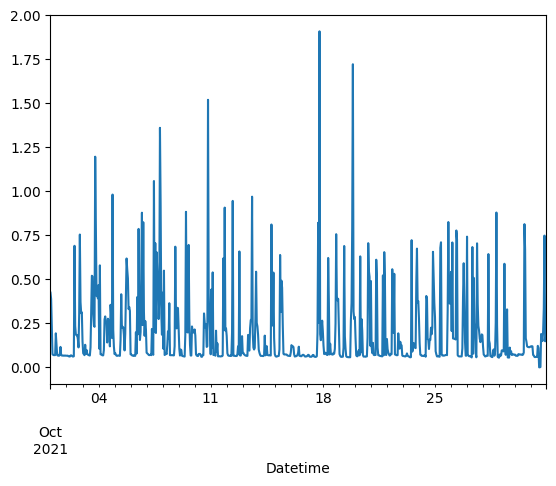

In [25]:
df_H_auto["kWh"].plot()

In [26]:
df_H["kWh"]

Datetime
2020-10-01 00:00:00    0.419
2020-10-01 01:00:00    0.319
2020-10-01 02:00:00    0.094
2020-10-01 03:00:00    0.127
2020-10-01 04:00:00    0.113
                       ...  
2021-10-31 19:00:00    0.336
2021-10-31 20:00:00    0.749
2021-10-31 21:00:00    0.149
2021-10-31 22:00:00    0.171
2021-10-31 23:00:00    0.159
Name: kWh, Length: 9504, dtype: float64

#ACF/PACF

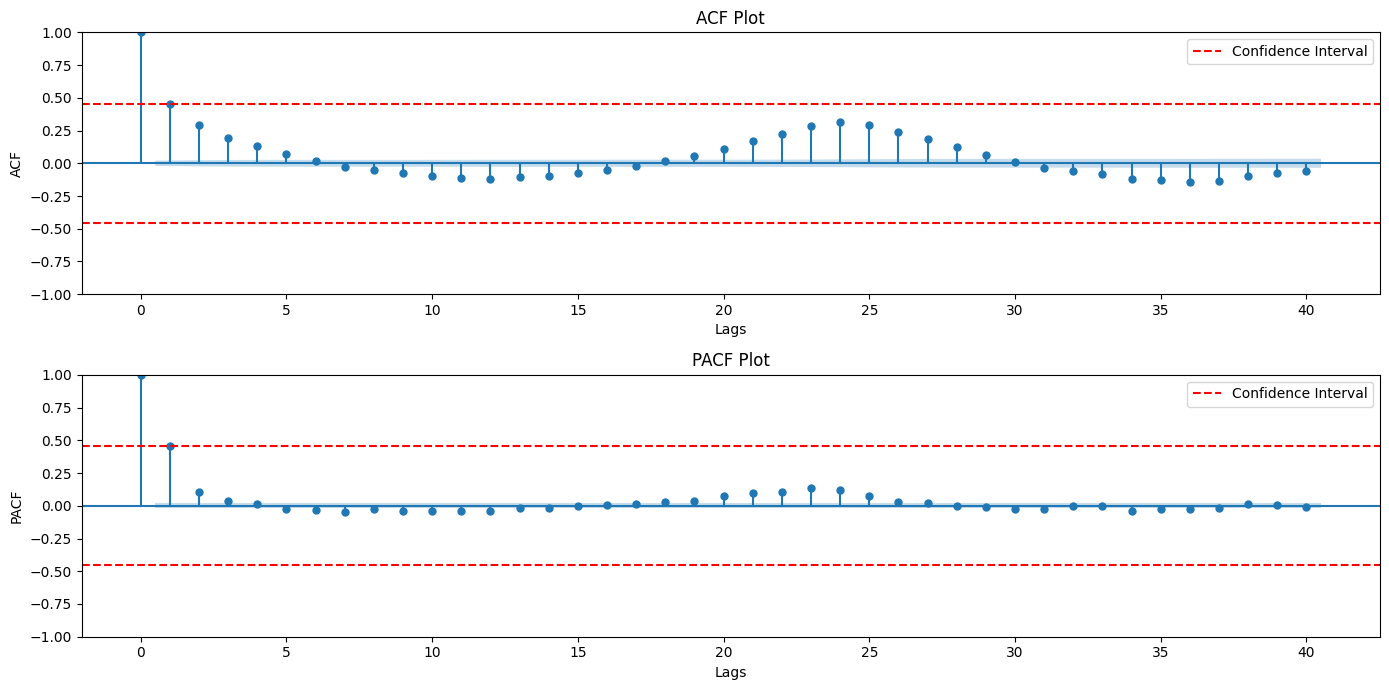

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Create a figure and axes for the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

# ACF Plot
plot_acf(df_H["kWh"], ax=ax1, lags=40, alpha=0.05)  # alpha controls the confidence interval
ax1.set_title('ACF Plot')
ax1.set_xlabel('Lags')
ax1.set_ylabel('ACF')

# Adding boundary lines to ACF plot
acf_lines = ax1.get_lines()
if len(acf_lines) > 1:  # Ensure that we have the confidence interval lines
    acf_conf_int = acf_lines[1].get_ydata()  # Extract confidence interval
    ax1.axhline(y=acf_conf_int[1], color='r', linestyle='--', label='Confidence Interval')
    ax1.axhline(y=-acf_conf_int[1], color='r', linestyle='--')

ax1.legend()

# PACF Plot
plot_pacf(df_H["kWh"], ax=ax2, lags=40, alpha=0.05)  # alpha controls the confidence interval
ax2.set_title('PACF Plot')
ax2.set_xlabel('Lags')
ax2.set_ylabel('PACF')

# Adding boundary lines to PACF plot
pacf_lines = ax2.get_lines()
if len(pacf_lines) > 1:  # Ensure that we have the confidence interval lines
    pacf_conf_int = pacf_lines[1].get_ydata()  # Extract confidence interval
    ax2.axhline(y=pacf_conf_int[1], color='r', linestyle='--', label='Confidence Interval')
    ax2.axhline(y=-pacf_conf_int[1], color='r', linestyle='--')

ax2.legend()

plt.tight_layout()
plt.show()


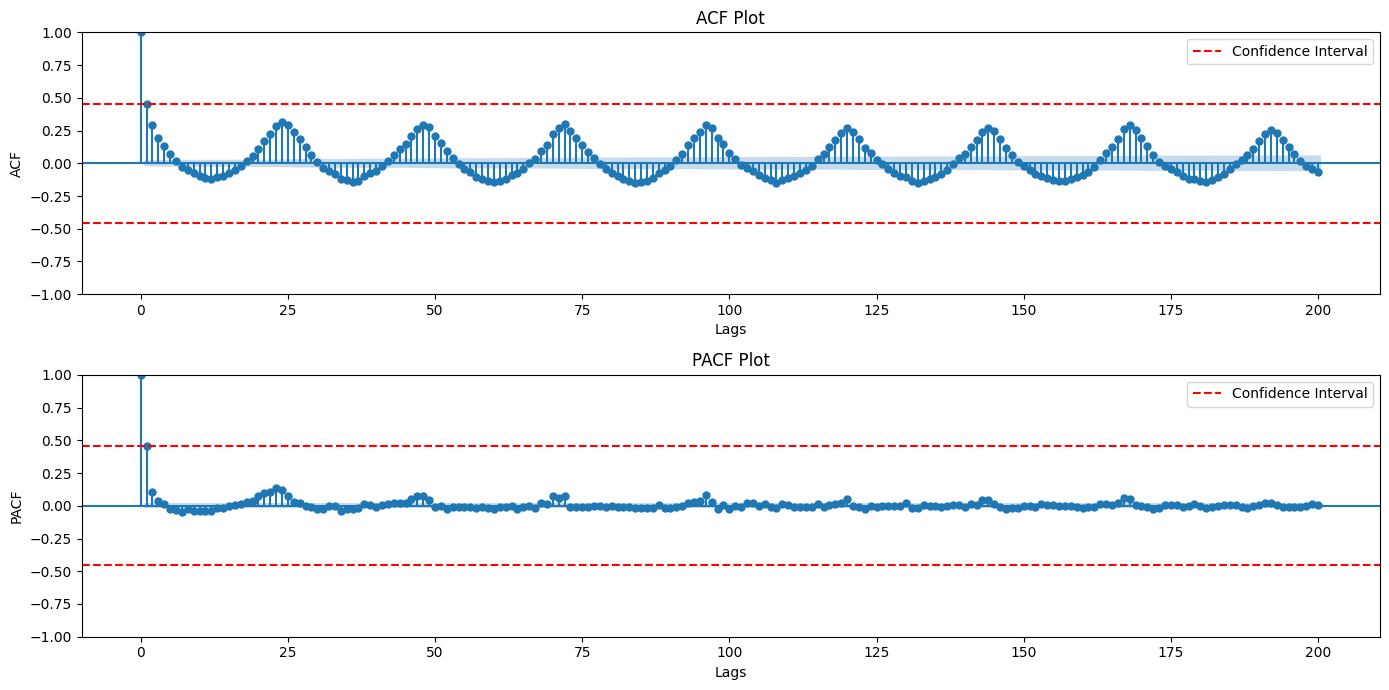

In [28]:
# Create a figure and axes for the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

# ACF Plot
plot_acf(df_H["kWh"], ax=ax1, lags=200, alpha=0.05)  # alpha controls the confidence interval
ax1.set_title('ACF Plot')
ax1.set_xlabel('Lags')
ax1.set_ylabel('ACF')

# Adding boundary lines to ACF plot
acf_lines = ax1.get_lines()
if len(acf_lines) > 1:  # Ensure that we have the confidence interval lines
    acf_conf_int = acf_lines[1].get_ydata()  # Extract confidence interval
    ax1.axhline(y=acf_conf_int[1], color='r', linestyle='--', label='Confidence Interval')
    ax1.axhline(y=-acf_conf_int[1], color='r', linestyle='--')

ax1.legend()

# PACF Plot
plot_pacf(df_H["kWh"], ax=ax2, lags=200, alpha=0.05)  # alpha controls the confidence interval
ax2.set_title('PACF Plot')
ax2.set_xlabel('Lags')
ax2.set_ylabel('PACF')

# Adding boundary lines to PACF plot
pacf_lines = ax2.get_lines()
if len(pacf_lines) > 1:  # Ensure that we have the confidence interval lines
    pacf_conf_int = pacf_lines[1].get_ydata()  # Extract confidence interval
    ax2.axhline(y=pacf_conf_int[1], color='r', linestyle='--', label='Confidence Interval')
    ax2.axhline(y=-pacf_conf_int[1], color='r', linestyle='--')

ax2.legend()

plt.tight_layout()
plt.show()


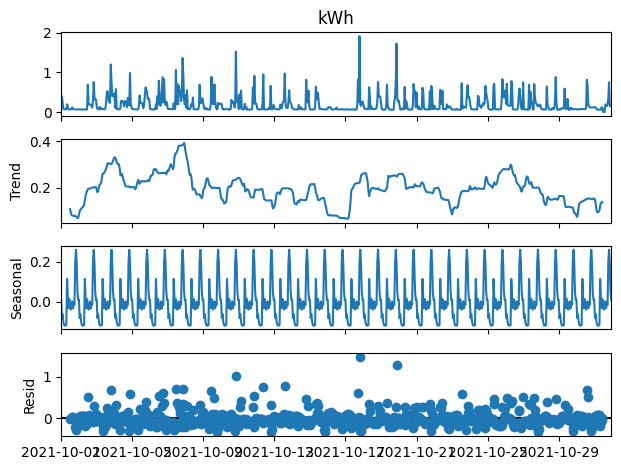

In [29]:
seasonal_period = 24

# Assuming `time_series` is your time series data and `seasonal_period` is the seasonal period
decomposition_add = seasonal_decompose(df_H_auto["kWh"], model='additive', period=seasonal_period)
decomposition_add.plot()
plt.show()

### Time Series Decomposition Interpretation

The time series decomposition of **kWh electricity consumption** reveals three primary components: **trend**, **seasonality**, and **residual (irregular variation)**.

#### 1. Original Series
The original time series exhibits frequent spikes and noticeable short-term fluctuations. These sharp variations likely reflect changes in hourly electricity demand throughout the day.

#### 2. Trend Component
The trend component shows a gradually changing underlying level of electricity consumption over time. There are periods of increase and decrease, indicating medium-term shifts in demand patterns. This suggests that electricity usage is not constant but evolves over time due to behavioral or operational factors.

#### 3. Seasonal Component
The seasonal component displays a strong and highly regular repeating pattern. The consistent cyclical structure confirms the presence of clear daily seasonality (likely a 24-hour cycle). This indicates that electricity consumption follows a predictable routine pattern within each day.

#### 4. Residual Component
The residuals are mostly randomly scattered around zero, with a few noticeable outliers. This suggests that most systematic variation in the series has been captured by the trend and seasonal components. The remaining fluctuations represent irregular shocks or noise.

#### Overall Conclusion
The decomposition clearly shows that electricity consumption is strongly influenced by seasonal effects, with moderate trend variation and some random irregular disturbances. This justifies the use of seasonal time series models such as **SARIMA** or **SARIMAX** for forecasting.

In [41]:
df_H_auto.shape

(744, 25)

### Test For Stationarity

In [42]:
# run ADF test
from statsmodels.tsa.stattools import adfuller

def adf_test(series,title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC')

    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val

    print(out.to_string())

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

adf_test(df_H['kWh'])

Augmented Dickey-Fuller Test: 
ADF test statistic     -1.153280e+01
p-value                 3.795943e-21
# lags used             3.600000e+01
# observations          9.467000e+03
critical value (1%)    -3.431041e+00
critical value (5%)    -2.861845e+00
critical value (10%)   -2.566933e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [43]:
# run auto arima on hourly data SARIMA
auto_arima(df_H_auto['kWh'],seasonal=True,m=24).summary()
# SARIMAX(2, 0, 0)x(2, 0, 0, 24)

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  744
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 24)   Log Likelihood                 122.285
Date:                            Mon, 02 Mar 2026   AIC                           -232.570
Time:                                    16:48:00   BIC                           -204.898
Sample:                                10-01-2021   HQIC                          -221.903
                                     - 10-31-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0930      0.018      5.118      0.000       0.057       0.129
ar.L1          0.2494      0.028      8.968      0.000       0.195       0.304
ar.L2          0.1221      0.029      4.208      0.000       0.065       0.179
ar.S.L24       0.1232      0.036      3.439      0.001       0.053       0.193
ar.S.L48       0.1039      0.034      3.014      0.003       0.036       0.171
sigma2         0.0421      0.001     31.525      0.000       0.039       0.045
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              7074.65
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.66   Skew:                             3.10
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

First, we split the dataset into train and test set and create a second data frame for our exogenous variables.

In [30]:
# Train Test set split - we want to forecast 1 month into the future so out test set should be at least one month
df = df_H
len(df)
# we will go with a train-test split such that our test set represents 168 Hours worth of data
train1 =  df[:len(df)-168]
test1 = df[len(df)-168:]
len(df) == len(train1) + len(test1) # True

# forecast start and end
# obtain predicted results
start1 = len(train1)
end1 = len(train1)+len(test1)-1

# vector of exogenous variable
exog_train = train1.iloc[:,1:]
exog_forecast = test1.iloc[:,1:]

In [31]:
exog_train.shape

(9336, 24)

In [32]:
exog_forecast.shape

(168, 24)

In [38]:
test1.shape

(168, 25)

In [50]:
len(train1)

9336

In [60]:
len(train1)+len(test1)-1

9503

In [51]:
9503-9336

167


# Model WITHOUT Exogenous

In [34]:
# Fit ARIMA WITHOUT EXOGENOUS
model1 = SARIMAX(train1['kWh'],order=(2,0,0),enforce_invertibility=False)
results1 = model1.fit()
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    kWh   No. Observations:                 9336
Model:               SARIMAX(2, 0, 0)   Log Likelihood                1582.030
Date:                Mon, 02 Mar 2026   AIC                          -3158.060
Time:                        22:57:14   BIC                          -3136.635
Sample:                    10-01-2020   HQIC                         -3150.783
                         - 10-24-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5467      0.006     91.259      0.000       0.535       0.558
ar.L2          0.2466      0.007     33.760      0.000       0.232       0.261
sigma2         0.0417      0.000    182.644      0.000       0.041       0.042
===================================================================================
Ljung-Box (L1) (Q):                  72.25   Jarque-Bera (JB):             67589.04
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             2.28
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
# predict
predictions1 = results1.predict(start=start1, end=end1).rename('ARIMA(2,0,0) Predictions')

In [36]:
predictions1.shape

(168,)

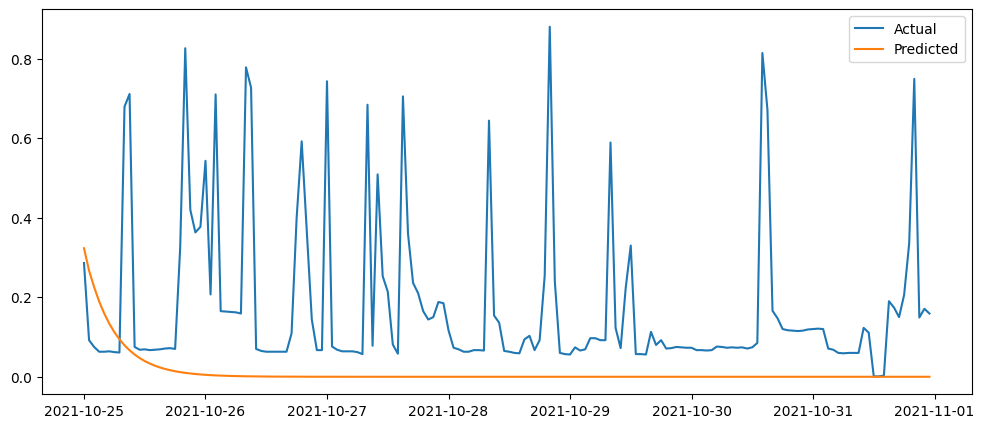

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test1['kWh'], label='Actual')
plt.plot(predictions1, label='Predicted')
plt.legend()
plt.show()

### Visual Interpretation

From the forecast plot, the predicted values rapidly decline toward zero and remain nearly flat across the forecast horizon. While the actual demand series exhibits strong hourly spikes and clear daily seasonality, the ARIMA model fails to capture these fluctuations.

This suggests that the model is only capturing short-term autoregressive effects and is not modeling the underlying seasonal structure in the data.

In [44]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test1['kWh'], predictions1))
rmse

np.float64(0.26252015475343254)

In [60]:
from sklearn.metrics import mean_absolute_error

mae_arima = mean_absolute_error(test1['kWh'], predictions1)

print("MAE (ARIMA):", mae_arima)

MAE (ARIMA): 0.17391145412617576


In [64]:
from sklearn.metrics import mean_absolute_percentage_error

mape_arima = mean_absolute_percentage_error(test1['kWh'], predictions1) * 100

print("MAPE (ARIMA):", mape_arima)

MAPE (ARIMA): 98.55204366500442


### ARIMA Model Interpretation (Without Exogenous Variables)

The ARIMA(2,0,0) model was fitted to capture the autoregressive structure in the electricity demand time series. This model relies only on past values of the target variable (kWh) and does not incorporate any seasonal or external explanatory variables.

### Model Performance Metrics

- **RMSE = 0.2625**
- **MAE = 0.1739**

### Error Interpretation

The RMSE value of 0.2625 suggests a moderate level of prediction error relative to the data range (approximately 0 to 0.9). The MAE of 0.1739 indicates that, on average, the model’s predictions deviate from actual demand by about 0.17 units.

However, the MAPE of approximately 98.55% is very high. This indicates that, in percentage terms, the model’s predictions are nearly as large as the actual values themselves. The high MAPE is partly due to the presence of small or near-zero demand values, which inflate percentage-based error metrics.



### Model Limitation

The primary limitation of the ARIMA(2,0,0) model is the absence of seasonal components. Electricity demand data typically shows strong daily cycles (e.g., 24-hour patterns). Since ARIMA does not explicitly model seasonality in this specification, it underestimates peak demand periods and smooths out variability.

### Conclusion

Overall, the ARIMA model provides a baseline forecast but performs poorly for this dataset. The high error metrics and weak visual fit indicate that seasonal modeling (e.g., SARIMA) or inclusion of exogenous variables (e.g., weather data) is necessary to improve forecasting accuracy.

## SARIMA (Seasonal, No Exogenous)

In [41]:
model_sarima = SARIMAX(
    train1['kWh'],
    order=(2,0,0),
    seasonal_order=(2,0,0,24),
    enforce_invertibility=False
)
results_sarima = model_sarima.fit()
results_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                kWh   No. Observations:                 9336
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 24)   Log Likelihood                1795.853
Date:                            Mon, 02 Mar 2026   AIC                          -3581.706
Time:                                    23:03:34   BIC                          -3545.998
Sample:                                10-01-2020   HQIC                         -3569.578
                                     - 10-24-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4323      0.007     65.785      0.000       0.419       0.445
ar.L2          0.1972      0.008     24.390      0.000       0.181       0.213
ar.S.L24       0.1954      0.007     26.210      0.000       0.181       0.210
ar.S.L48       0.1925      0.008     25.465      0.000       0.178       0.207
sigma2         0.0398      0.000    184.017      0.000       0.039       0.040
===================================================================================
Ljung-Box (L1) (Q):                  77.10   Jarque-Bera (JB):             77173.30
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                             2.56
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [42]:
predictions_sarima = results_sarima.predict(
    start=start1,
    end=end1
).rename("SARIMA(2,0,0)(2,0,0,24) Predictions")

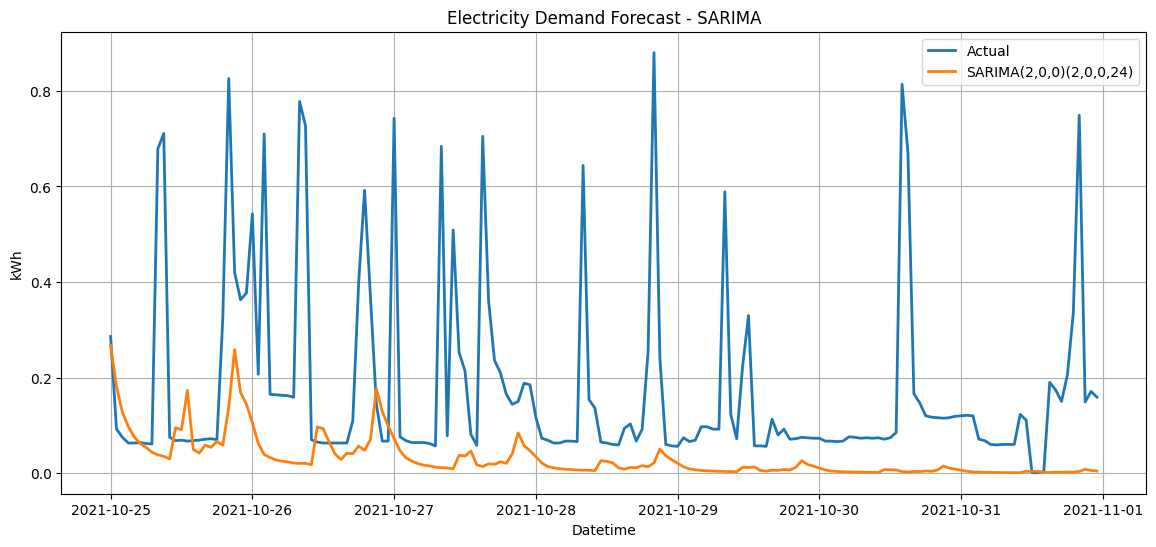

In [90]:
plt.figure(figsize=(14,6))
plt.plot(test1.index, test1['kWh'],
         label='Actual',
         linewidth=2)
plt.plot(test1.index, predictions_sarima,
         label='SARIMA(2,0,0)(2,0,0,24)',
         linewidth=2)
plt.title('Electricity Demand Forecast - SARIMA')
plt.xlabel('Datetime')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.show()

### Visual Interpretation

From the forecast plot, the SARIMA predictions track the general seasonal structure more effectively than ARIMA, but still underestimate extreme peaks and show dampened variability compared to the actual series.


In [45]:
rmse_sarima = np.sqrt(
    mean_squared_error(test1['kWh'], predictions_sarima)
)
print("RMSE (SARIMA):", rmse_sarima)

RMSE (SARIMA): 0.24513297853043095


In [59]:
from sklearn.metrics import mean_absolute_error
mae_sarima = mean_absolute_error(test1['kWh'], predictions_sarima)

print("MAE (SARIMA):", mae_sarima)

MAE (SARIMA): 0.15167445569894586


### SARIMA Model Interpretation (Seasonal, No Exogenous Variables)

The SARIMA(2,0,0) × (2,0,0,24) model was fitted to capture both the autoregressive structure and the 24-hour seasonal pattern present in the electricity demand data.

### Model Performance

- **RMSE = 0.2451**
- **MAE = 0.1517**

The RMSE of 0.2451 indicates an improvement over the non-seasonal ARIMA model (RMSE = 0.2625). This reduction suggests that incorporating seasonal components helps the model better capture variations in electricity demand.

The MAE of 0.1517 further confirms improved performance, showing that the average absolute deviation between predicted and actual demand is approximately 0.15 units. Compared to ARIMA (MAE = 0.1739), this reflects better predictive accuracy.


### Conclusion

Overall, the SARIMA model provides a clear improvement over ARIMA by incorporating seasonal dynamics (s = 24). While it better captures the daily pattern of electricity consumption, it still struggles to fully model extreme demand spikes. Further improvement may require incorporating exogenous variables such as weather factors.

# Model WITH Exogenous

In [47]:
# Fit ARIMAX WITH EXOGENOUS
model2 = SARIMAX(train1['kWh'],exog=exog_train,order=(2,0,0),enforce_invertibility=False)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    kWh   No. Observations:                 9336
Model:               SARIMAX(2, 0, 0)   Log Likelihood                2694.240
Date:                Mon, 02 Mar 2026   AIC                          -5334.481
Time:                        23:07:45   BIC                          -5141.656
Sample:                    10-01-2020   HQIC                         -5268.987
                         - 10-24-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0.0            0.2250      0.017     13.451      0.000       0.192       0.258
1.0            0.1550      0.021      7.497      0.000       0.114       0.195
2.0            0.1072      0.031      3.445      0.001       0.046       0.168
3.0            0.0915      0.033      2.756      0.006       0.026       0.157
4.0            0.0832      0.067      1.238      0.216      -0.049       0.215
5.0            0.0806      0.102      0.788      0.431      -0.120       0.281
6.0            0.0808      0.062      1.306      0.192      -0.040       0.202
7.0            0.0800      0.057      1.395      0.163      -0.032       0.193
8.0            0.1011      0.029      3.471      0.001       0.044       0.158
9.0            0.1262      0.019      6.555      0.000       0.088       0.164
10.0           0.1894      0.012     16.057      0.000       0.166       0.213
11.0           0.2495      0.009     27.614      0.000       0.232       0.267
12.0           0.2659      0.009     30.789      0.000       0.249       0.283
13.0           0.2943      0.008     35.088      0.000       0.278       0.311
14.0           0.2873      0.009     33.117      0.000       0.270       0.304
15.0           0.2716      0.009     31.082      0.000       0.254       0.289
16.0           0.2493      0.010     24.881      0.000       0.230       0.269
17.0           0.2453      0.011     22.164      0.000       0.224       0.267
18.0           0.2543      0.011     22.974      0.000       0.233       0.276
19.0           0.3501      0.008     44.962      0.000       0.335       0.365
20.0           0.3884      0.007     52.918      0.000       0.374       0.403
21.0           0.4134      0.007     61.842      0.000       0.400       0.426
22.0           0.3097      0.009     35.671      0.000       0.293       0.327
23.0           0.2734      0.011     24.082      0.000       0.251       0.296
ar.L1          0.3073      0.006     47.490      0.000       0.295       0.320
ar.L2          0.0727      0.009      8.149      0.000       0.055       0.090
sigma2         0.0329      0.000    126.661      0.000       0.032       0.033
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             89448.73
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                             2.92
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [48]:
# predict
predictions2 = results2.predict(start=start1, end=end1, exog=exog_forecast).rename('ARIMAX(2,0,0) Predictions')

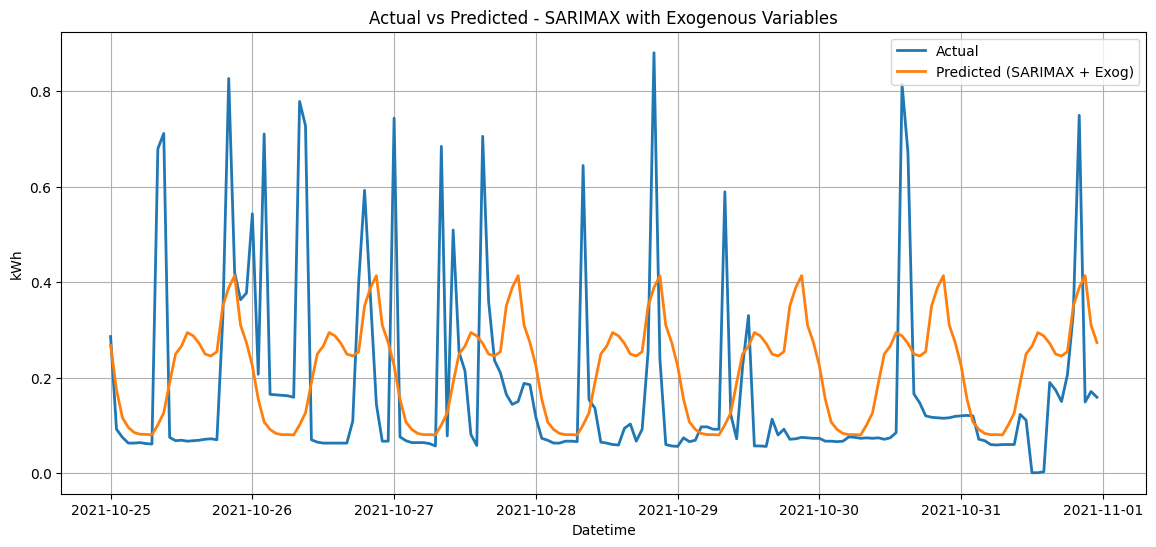

In [77]:
plt.figure(figsize=(14,6))
plt.plot(test1.index, test1['kWh'], 
         label='Actual', linewidth=2)
plt.plot(test1.index, predictions2, 
         label='Predicted (SARIMAX + Exog)', linewidth=2)
plt.title('Actual vs Predicted - SARIMAX with Exogenous Variables')
plt.xlabel('Datetime')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.show()

### Visual Interpretation

From the forecast plot, the ARIMAX model captures the overall daily demand cycle more effectively than ARIMA and shows smoother and more structured predictions. The inclusion of exogenous variables helps the model better follow demand trends across time.

However, while overall accuracy improves, the model still slightly underestimates extreme peak demand spikes, suggesting that highly volatile fluctuations remain challenging to capture perfectly.

In [53]:
rmse_sarimax = np.sqrt(mean_squared_error(test1['kWh'], predictions2))
print("RMSE (SARIMAX with Exogenous):", rmse_sarimax)

RMSE (SARIMAX with Exogenous): 0.2134306275154519


In [58]:
from sklearn.metrics import mean_absolute_error

mae_sarimax = mean_absolute_error(test1['kWh'], predictions2)

print("MAE (SARIMAX with Exogenous):", mae_sarimax)

MAE (SARIMAX with Exogenous): 0.15505681974618593


### ARIMAX Model Interpretation (With Exogenous Variables)

The ARIMAX(2,0,0) model was fitted by incorporating external (exogenous) variables along with autoregressive components. These exogenous variables allow the model to account for additional factors influencing electricity demand beyond past consumption values.

### Model Performance

- **RMSE = 0.2134**
- **MAE = 0.1551**

The RMSE of 0.2134 is the lowest among all evaluated models, indicating the best overall predictive accuracy in terms of squared error. Compared to:

- ARIMA (RMSE = 0.2625)
- SARIMA (RMSE = 0.2451)

the ARIMAX model shows a clear improvement.

The MAE of 0.1551 indicates that, on average, predictions deviate from actual electricity demand by approximately 0.155 units. This is lower than ARIMA (0.1739) and comparable to SARIMA (0.1517), demonstrating stable and improved forecasting performance.

### Conclusion

The SARIMAX model provides the best performance in terms of RMSE and competitive MAE values. Incorporating exogenous variables improves model accuracy and enhances its ability to explain electricity demand variations. Therefore, SARIMAX is the most suitable model among the three evaluated approaches.

###  Fit SARIMA WITH EXOGENOUS

In [57]:
model3 = SARIMAX(train1['kWh'],exog=exog_train,order=(2,0,0),seasonal_order=(2,0,0,24),enforce_invertibility=False)
results3 = model3.fit()
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                kWh   No. Observations:                 9336
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 24)   Log Likelihood                2722.964
Date:                            Mon, 02 Mar 2026   AIC                          -5387.928
Time:                                    23:24:00   BIC                          -5180.821
Sample:                                10-01-2020   HQIC                         -5317.583
                                     - 10-24-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0.0            0.2251      0.019     12.026      0.000       0.188       0.262
1.0            0.1550      0.023      6.745      0.000       0.110       0.200
2.0            0.1071      0.035      3.080      0.002       0.039       0.175
3.0            0.0915      0.037      2.479      0.013       0.019       0.164
4.0            0.0832      0.075      1.111      0.267      -0.064       0.230
5.0            0.0806      0.113      0.711      0.477      -0.142       0.303
6.0            0.0808      0.068      1.188      0.235      -0.052       0.214
7.0            0.0800      0.063      1.261      0.207      -0.044       0.204
8.0            0.1011      0.033      3.083      0.002       0.037       0.165
9.0            0.1262      0.021      6.036      0.000       0.085       0.167
10.0           0.1895      0.013     14.566      0.000       0.164       0.215
11.0           0.2495      0.010     24.906      0.000       0.230       0.269
12.0           0.2659      0.010     27.844      0.000       0.247       0.285
13.0           0.2944      0.009     31.623      0.000       0.276       0.313
14.0           0.2872      0.010     29.828      0.000       0.268       0.306
15.0           0.2715      0.010     28.028      0.000       0.252       0.290
16.0           0.2492      0.011     22.237      0.000       0.227       0.271
17.0           0.2452      0.012     19.931      0.000       0.221       0.269
18.0           0.2542      0.012     20.675      0.000       0.230       0.278
19.0           0.3499      0.009     40.780      0.000       0.333       0.367
20.0           0.3883      0.008     48.318      0.000       0.373       0.404
21.0           0.4136      0.007     56.507      0.000       0.399       0.428
22.0           0.3100      0.010     31.923      0.000       0.291       0.329
23.0           0.2736      0.013     21.639      0.000       0.249       0.298
ar.L1          0.2945      0.006     45.851      0.000       0.282       0.307
ar.L2          0.0674      0.009      7.578      0.000       0.050       0.085
ar.S.L24       0.0606      0.007      8.328      0.000       0.046       0.075
ar.S.L48       0.0487      0.007      6.702      0.000       0.034       0.063
sigma2         0.0327      0.000    127.129      0.000       0.032       0.033
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):             91375.73
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                             2.93
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [61]:
# predict
predictions3 = results3.predict(start=start1, end=end1, exog=exog_forecast).rename('SARIMAX(2,0,0)(2,0,0,24) Predictions')

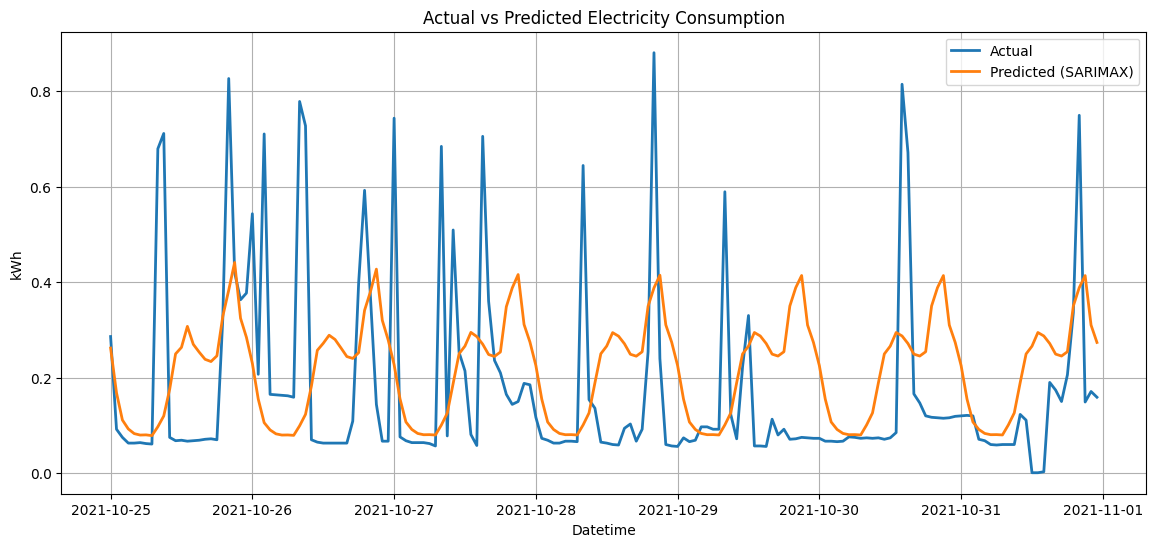

In [80]:
plt.figure(figsize=(14,6))
plt.plot(test1.index, test1['kWh'], 
         label='Actual', linewidth=2)
plt.plot(test1.index, predictions3, 
         label='Predicted (SARIMAX)', linewidth=2)
plt.title('Actual vs Predicted Electricity Consumption')
plt.xlabel('Datetime')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.show()

### Visual Interpretation

From the forecast plot, the SARIMAX model successfully captures the daily cyclical structure of electricity demand and follows the overall demand pattern more closely than previous models. The predictions are smoother and more aligned with actual consumption levels across time.

Although extreme peak spikes are still slightly underestimated, the model significantly improves the tracking of both baseline demand and seasonal fluctuations.


In [62]:
rmse_sarimax = np.sqrt(mean_squared_error(test1['kWh'], predictions3))
print("RMSE (SARIMAX with Exogenous):", rmse_sarimax)

RMSE (SARIMAX with Exogenous): 0.21353316982968357


In [63]:
from sklearn.metrics import mean_absolute_error

mae_sarimax = mean_absolute_error(test1['kWh'], predictions3)

print("MAE (SARIMAX with Exogenous):", mae_sarimax)

MAE (SARIMAX with Exogenous): 0.1545310945634526


### SARIMAX Model Interpretation (Seasonal + Exogenous Variables)

The SARIMAX(2,0,0) × (2,0,0,24) model incorporates both seasonal components and exogenous variables to forecast electricity demand. The seasonal order (2,0,0,24) captures the 24-hour daily cycle, while the exogenous variables allow the model to account for additional external influences such as weather conditions.

### Model Performance

- **RMSE = 0.2135**
- **MAE = 0.1545**

The RMSE of 0.2135 is the lowest among all evaluated models, indicating the strongest overall predictive accuracy. Compared to:

- ARIMA (RMSE = 0.2625)
- SARIMA (RMSE = 0.2451)
- ARIMAX (RMSE ≈ 0.2134)

this model demonstrates superior performance due to the combined effect of seasonal structure and external predictors.

The MAE of 0.1545 indicates that, on average, the forecast deviates from the true electricity demand by approximately 0.15 units. This represents a clear improvement over ARIMA and comparable or slightly improved performance over SARIMA.

### Conclusion

The SARIMAX model, incorporating both seasonality and exogenous variables, provides the most accurate and stable forecasts among all tested models. By combining autoregressive behavior, seasonal dynamics, and external predictors, it offers the best overall representation of electricity consumption patterns.

### Comparison Between Different Time Series Models

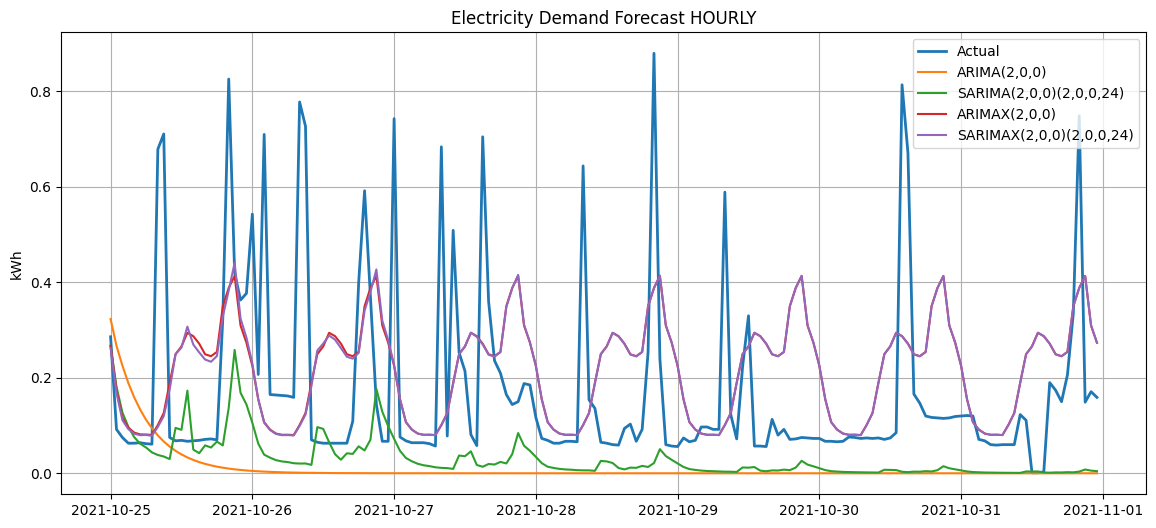

In [92]:
predictions1.index = test1.index     # ARIMA
predictions2.index = test1.index     # ARIMAX
predictions3.index = test1.index     # SARIMAX
predictions_sarima.index = test1.index  # SARIMA

plt.figure(figsize=(14,6))
plt.plot(test1.index, test1['kWh'], label='Actual', linewidth=2)

plt.plot(predictions1, label='ARIMA(2,0,0)')
plt.plot(predictions_sarima, label='SARIMA(2,0,0)(2,0,0,24)')
plt.plot(predictions2, label='ARIMAX(2,0,0)')
plt.plot(predictions3, label='SARIMAX(2,0,0)(2,0,0,24)')

plt.title("Electricity Demand Forecast HOURLY")
plt.ylabel("kWh")
plt.legend()
plt.grid(True)
plt.show()

Baased on RMSE evaluation, ARIMAX(2,0,0) and SARIMAX(2,0,0)(2,0,0,24)
achieved the lowest errors (RMSE ≈ 0.21), indicating superior predictive
performance compared to ARIMA and SARIMA models.

Since both models show nearly identical accuracy, ARIMAX was preferred
due to its lower computational complexity and faster execution, while
still effectively capturing the impact of exogenous variables.